In [1]:
import os
import mujoco
import mujoco.viewer
import mediapy as media
import matplotlib.pyplot as plt
import time
import itertools
import numpy as np
from pathlib import Path

In [2]:
#Carga de los modelos de mujoco
#Parámetros de la piernas
#Implementar lo siguiente cuando aprenda a hacerlo
#from .config import R_HIP_LEN, R_KNEE_LEN, R_ANKLE_LEN,F_HIP_LEN, F_KNEE_LEN, F_ANKLE_LEN,SCALE

SCALE = 1
R_HIP_LEN = 0.166 * SCALE
R_KNEE_LEN = 0.231 * SCALE
R_ANKLE_LEN = 0.148 * SCALE
F_HIP_LEN =  0.121 * SCALE
F_KNEE_LEN = 0.111 * SCALE
#tener en cuenta o no tener en cuenta la escápla, eso añadiria ortro grado de libertad
#Le voy a sumar la longitud de los falanges en vez de añadir otro grado de liberad
F_ANKLE_LEN = (0.0802+0.0288+0.0188+0.0256) * SCALE 

FRAMERATE = 30

path = Path.cwd().parent / 'assets' / 'xml' / 'pata_trasera_bonilla.xml'

with open(path, "r") as file:
    xml_temp = file.read()

base_values = {
    "thigh": (0.03, 1.68),
    "shank": (0.025, 0.795),
    "metatarsus": (0.02, 0.099)
}
# Compute scaled values
scaled_values_front = {}
for name, (size, mass) in base_values.items():
    scaled_values_front[f"{name}_size"] = size * SCALE
    scaled_values_front[f"{name}_mass"] = mass * SCALE

scaled_values_back = {}
for name, (size, mass) in base_values.items():
    scaled_values_back[f"{name}_size"] = size * SCALE
    scaled_values_back[f"{name}_mass"] = mass * SCALE

xml_front = xml_temp.format(
    thigh_len=F_HIP_LEN,
    shank_len=F_KNEE_LEN,
    metatarsus_len=F_ANKLE_LEN,
    plane_len=F_HIP_LEN+F_KNEE_LEN+F_ANKLE_LEN,
    **scaled_values_front
)

xml_back=xml_temp.format(
    thigh_len=R_HIP_LEN,
    shank_len=R_KNEE_LEN,
    metatarsus_len=R_ANKLE_LEN,
    plane_len=R_HIP_LEN+R_KNEE_LEN+R_ANKLE_LEN,
    **scaled_values_back
)

model_front_leg=mujoco.MjModel.from_xml_string(xml_front)
data_front = mujoco.MjData(model_front_leg)
model_back_leg=mujoco.MjModel.from_xml_string(xml_back)
data_back = mujoco.MjData(model_back_leg)

""

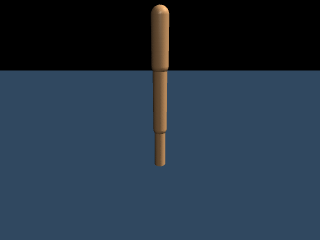

In [3]:
#back leg
renderer_back=mujoco.Renderer(model_back_leg)
mujoco.mj_forward(model_back_leg,data_back)
renderer_back.update_scene(data_back,camera="main_cam")
media.show_image(renderer_back.render())
renderer_back.close()

""

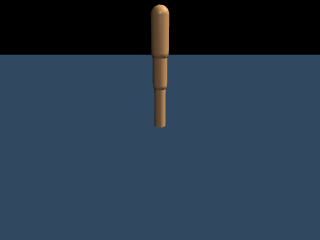

In [4]:
#front leg
renderer_front=mujoco.Renderer(model_front_leg)
mujoco.mj_forward(model_front_leg,data_front)
renderer_front.update_scene(data_front,camera="main_cam")
media.show_image(renderer_front.render())
renderer_front.close()

In [5]:
print(R_KNEE_LEN +R_ANKLE_LEN+R_HIP_LEN)
print(F_KNEE_LEN +F_ANKLE_LEN+F_HIP_LEN)

0.545
0.3854
